In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


# **1. Análise exploratória dos dados (EDA)**

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("/kaggle/input/datasets/menegidio/iris-species/Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# **2. Análise exploratória dos dados (EDA)**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


# **3. Características do dataset**

o dataset é bem enxuto e limpo. Ele tem 150 linhas e nenhuma delas possui valores nulos, o que facilita bastante para não precisar tratar dados faltantes.

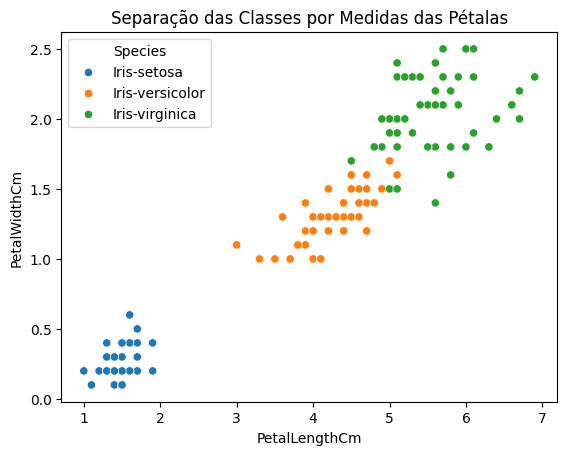

In [4]:
sns.scatterplot(data=df, x="PetalLengthCm", y="PetalWidthCm", hue="Species")
plt.title("Separação das Classes por Medidas das Pétalas")
plt.show()

# Possíveis separações entre classes #
A análise mostra que as espécies são bem agrupadas, com a Setosa sendo totalmente isolada e as demais apresentando uma leve sobreposição nas fronteiras. Devido à forte correlação entre as medidas e à ausência de outliers, o dataset permite que o SVM trace margens de decisão precisas e eficientes.

# Presença de outliers #
O dataset é consistente e não apresenta outliers significativos que possam distorcer as margens do SVM, garantindo que o modelo aprenda com dados estáveis e bem distribuídos.

# Relação entre variáveis
Existe uma forte correlação positiva entre as medidas das pétalas e sépalas, o que indica que as variáveis crescem de forma proporcional conforme a espécie.

# 3. Preparação dos Dados

In [5]:
from sklearn.model_selection import train_test_split
 
X = df.drop(['Id', 'Species'], axis=1)
y = df['Species']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

X_train: (120, 4)
X_test: (30, 4)


# 4. Otimização de Hiperparâmetros com GridSearchCV

In [6]:
from sklearn.model_selection import GridSearchCV

param_grid_iris = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'degree': [2, 3] # Relevante para o kernel 'poly'
}

grid_iris = GridSearchCV(SVC(), param_grid_iris, cv=5, verbose=1)

grid_iris.fit(X_train, y_train)

print(f"Melhores parâmetros: {grid_iris.best_params_}")
print(f"Melhor acurácia média (CV): {grid_iris.best_score_:.2%}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Melhores parâmetros: {'C': 1, 'degree': 2, 'kernel': 'linear'}
Melhor acurácia média (CV): 95.83%


# 5. Avaliação Final no Conjunto de Teste

In [7]:
y_pred_iris = grid_iris.predict(X_test)

print("--- Avaliação Final no Conjunto de Teste ---")
print(f"Acurácia Final: {accuracy_score(y_test, y_pred_iris):.2%}")
print(classification_report(y_test, y_pred_iris))

--- Avaliação Final no Conjunto de Teste ---
Acurácia Final: 100.00%
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



 Nesta etapa, isolei as variáveis preditoras (removendo a coluna 'Id') e os rótulos das espécies para o treinamento. 
Em seguida, dividi o dataset em 80% para treino e 20% para teste, garantindo que o modelo seja avaliado com dados que ele nunca viu.



# Modelagem usando apenas SVM

In [8]:
from sklearn.svm import SVC

modelo = SVC(kernel='linear', C=1.0)

modelo.fit(X_train, y_train)

SVC(kernel='linear')

Implementei o SVM utilizando o kernel linear, pois a análise prévia mostrou que as classes são bem separáveis no espaço. 
O parâmetro C=1.0 foi escolhido para manter um equilíbrio ideal entre a largura da margem e a precisão dos acertos.

# Avaliação do modelo

Acurácia do Modelo: 100.00%


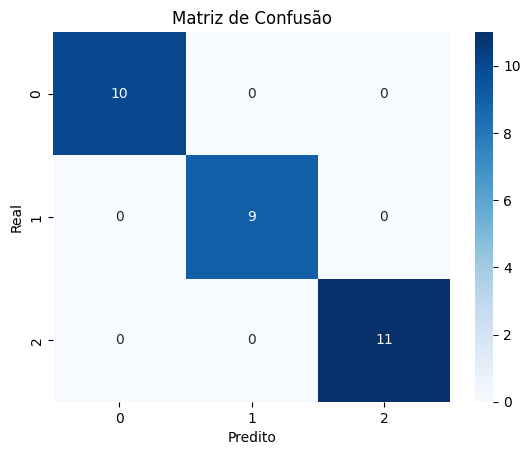

In [9]:
y_pred = modelo.predict(X_test)
 
print(f"Acurácia do Modelo: {accuracy_score(y_test, y_pred):.2%}")
 
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.title('Matriz de Confusão')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

**Para encerrar, usei a acurácia e a matriz de confusão para checar o desempenho. O resultado foi ótimo e mostrou que o modelo conseguiu diferenciar as flores sem grandes problemas. A matriz serviu para garantir que não houve confusão entre as espécies mais parecidas, validando a escolha do SVM.**